# Random Forest — Strategy B: Class Weighting

This notebook trains and evaluates a Random Forest classifier using Strategy B for class imbalance handling. In this strategy, the original training distribution is preserved and class imbalance is handled by setting `class_weight="balanced"`.

The model is trained on the preprocessed training set and evaluated on the original untouched test set. The results are saved for later comparison with the SMOTE-based Random Forest model and the other machine learning models.

In [1]:
import pandas as pd

In [2]:
X_train_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_train_final.parquet")
X_test_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_test_final.parquet")

y_train = pd.read_parquet("../DATASETS/PREPROCESSED/y_train.parquet")["diabetes"]
y_test = pd.read_parquet("../DATASETS/PREPROCESSED/y_test.parquet")["diabetes"]

In [ ]:
# Balancing

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    class_weight="balanced",
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_final, y_train)

y_pred = model.predict(X_test_final)
y_pred_proba = model.predict_proba(X_test_final)[:, 1]

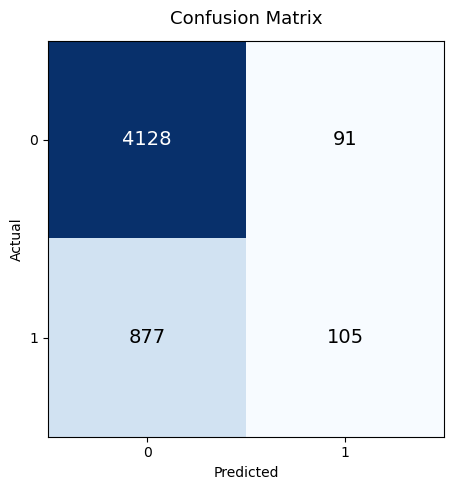

In [9]:
# Plotting confusion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

conf_matrix = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title("Confusion Matrix", color="black", fontsize=13, pad=12)
ax.set_xlabel("Predicted", color="black")
ax.set_ylabel("Actual", color="black")
ax.tick_params(colors="black")

for text in disp.text_.ravel():
    text.set_color("black")
    text.set_fontsize(14)
disp.text_[0, 0].set_color("white")

plt.tight_layout()
plt.show()

In [10]:
# Results

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8139
ROC AUC: 0.7896
Confusion Matrix:
[[4128   91]
 [ 877  105]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.98      0.90      4219
         1.0       0.54      0.11      0.18       982

    accuracy                           0.81      5201
   macro avg       0.68      0.54      0.54      5201
weighted avg       0.77      0.81      0.76      5201

